In [1]:
import matplotlib as plt 
import pandas as pd 
import yfinance as yf 

START_DATE = (pd.Timestamp.today() - pd.DateOffset(years=20)).strftime("%Y-%m-%d")
df = yf.download("^GSPC", start=START_DATE).dropna()
df.to_csv("SP500_daily.csv", index=True)

[*********************100%***********************]  1 of 1 completed


In [2]:
!pip install yfinance

In [3]:
#weekly returns 
weekly = df["Close"].resample("W-FRI").last().pct_change().dropna()
weekly = weekly.squeeze()
weekly_returns = pd.DataFrame({"Week": weekly.index, "Return (%)": weekly.values * 100})


<function subplots at 0x151135440>


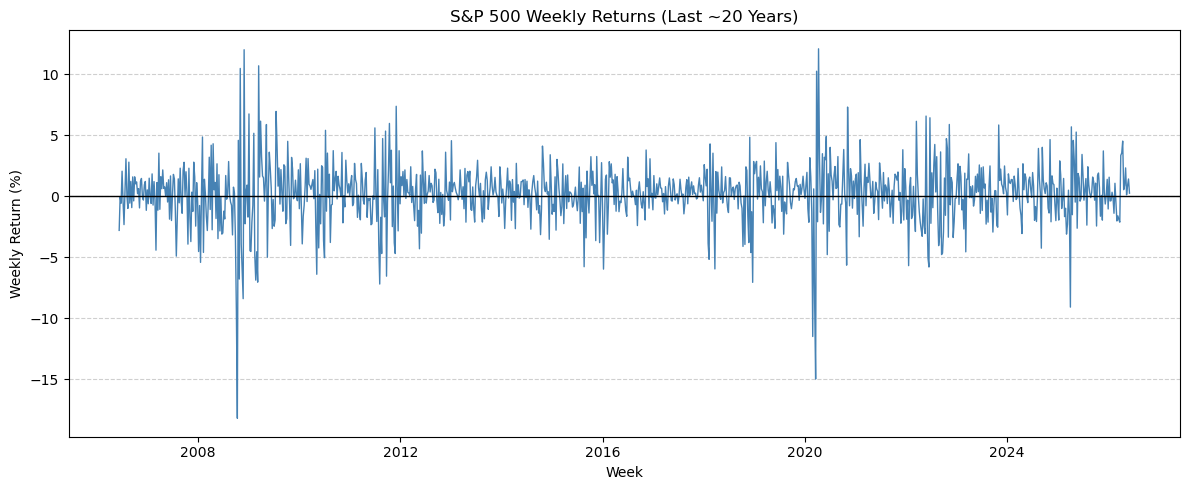

In [8]:
#troubleshot it 
import importlib
import matplotlib
importlib.reload(matplotlib)
import matplotlib.pyplot as plt
print(plt.subplots)



fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weekly_returns["Week"], weekly_returns["Return (%)"], color="steelblue", linewidth=1)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("S&P 500 Weekly Returns (Last ~20 Years)")
ax.set_xlabel("Week")
ax.set_ylabel("Weekly Return (%)")
ax.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

<function subplots at 0x151135440>
